# Importing Modules

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df = pd.read_csv('credit_fraud_data.csv')

# Exploring the Data

In [3]:
print('the shape of data is: ', df.shape)
df.head()

the shape of data is:  (31281, 10)


,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41,2453.81,12686.50,21,no,9,no,2438.2,5.2,no
1,49,1574.12,36337.02,37,no,4,no,2967.1,8.4,yes
2,38,14897.42,23295.64,21,no,0,no,4703.6,3.7,no
3,38,9927.23,38586.08,46,no,17,no,4281.2,5.5,yes
4,61,12914.13,2013.73,34,no,11,no,4366.7,9.7,yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31281 entries, 0 to 31280
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     31281 non-null  int64  
 1   transaction_amount      31281 non-null  float64
 2   account_balance         31281 non-null  float64
 3   num_transactions_today  31281 non-null  int64  
 4   is_foreign_transaction  31281 non-null  str    
 5   transaction_hour        31281 non-null  int64  
 6   prev_fraud_flag         31281 non-null  str    
 7   merchant_distance_km    31281 non-null  float64
 8   merchant_risk_score     31281 non-null  float64
 9   is_fraud                31281 non-null  str    
dtypes: float64(4), int64(3), str(3)
memory usage: 2.4 MB


In [5]:
binary_col = ['is_foreign_transaction','prev_fraud_flag','is_fraud']
for col in binary_col:
    df[col] = df[col].map({'yes':1, 'no':0})

In [6]:
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41,2453.81,12686.50,21,0,9,0,2438.2,5.2,0
1,49,1574.12,36337.02,37,0,4,0,2967.1,8.4,1
2,38,14897.42,23295.64,21,0,0,0,4703.6,3.7,0
3,38,9927.23,38586.08,46,0,17,0,4281.2,5.5,1
4,61,12914.13,2013.73,34,0,11,0,4366.7,9.7,1


In [7]:
df.describe()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
count,31281.000000,31281.000000,31281.000000,31281.000000,31281.000000,31281.000000,31281.000000,31281.000000,31281.000000,31281.00000
mean,46.048911,7465.260077,25020.058116,24.952559,0.143442,11.457051,0.079090,2501.023991,5.506776,0.48189
std,16.467816,4281.045583,14281.473610,13.998469,0.350528,6.844852,0.269883,1429.814413,2.568499,0.49968
min,18.000000,1.070000,-99999.000000,1.000000,0.000000,0.000000,0.000000,0.100000,1.000000,0.00000
25%,32.000000,3800.930000,12745.370000,13.000000,0.000000,6.000000,0.000000,1279.600000,3.300000,0.00000
50%,46.000000,7458.960000,25042.450000,25.000000,0.000000,11.000000,0.000000,2501.040408,5.506798,0.00000
75%,60.000000,11125.280000,37277.340000,37.000000,0.000000,17.000000,0.000000,3715.800000,7.700000,1.00000
max,74.000000,14999.710000,49998.900000,49.000000,1.000000,23.000000,1.000000,4999.800000,10.000000,1.00000


<Axes: xlabel='account_balance'>

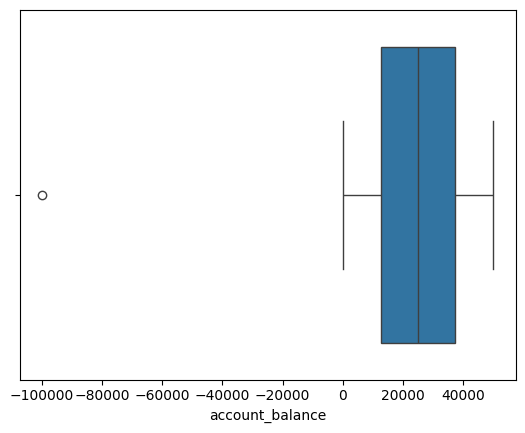

In [8]:
sns.boxplot(x = 'account_balance', data = df)

<Axes: xlabel='transaction_amount'>

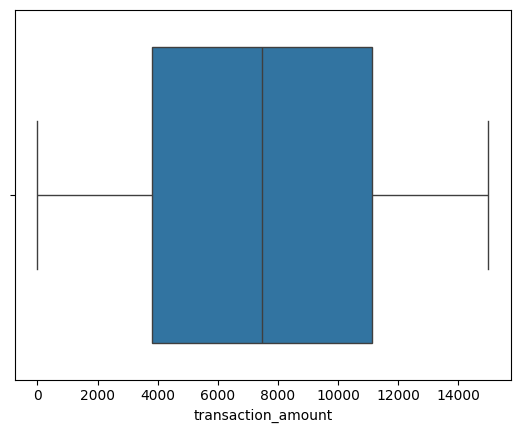

In [9]:
sns.boxplot(x = 'transaction_amount', data = df)

# Removing Outliers

In [10]:
df = df[df['account_balance'] > 100]

In [11]:
Q1 = df['transaction_amount'].quantile(0.25)
Q3 = df['transaction_amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['transaction_amount'] >= lower) & (df['transaction_amount'] <= upper)]

# Explotary Data Analysis and Visualization

In [12]:
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41,2453.81,12686.50,21,0,9,0,2438.2,5.2,0
1,49,1574.12,36337.02,37,0,4,0,2967.1,8.4,1
2,38,14897.42,23295.64,21,0,0,0,4703.6,3.7,0
3,38,9927.23,38586.08,46,0,17,0,4281.2,5.5,1
4,61,12914.13,2013.73,34,0,11,0,4366.7,9.7,1


In [13]:
df['is_fraud'].value_counts(normalize = True)

is_fraud
0    0.518052
1    0.481948
Name: proportion, dtype: float64

In [14]:
fraud = df[df['is_fraud'] == 1]
not_fraud = df[df['is_fraud'] == 0]

In [15]:
print('Fraud percentage: ',fraud['is_foreign_transaction'].value_counts(normalize = True))
print('Not fraud percentage: ',not_fraud['is_foreign_transaction'].value_counts(normalize = True))

Fraud percentage:  is_foreign_transaction
0    0.770207
1    0.229793
Name: proportion, dtype: float64
Not fraud percentage:  is_foreign_transaction
0    0.9368
1    0.0632
Name: proportion, dtype: float64


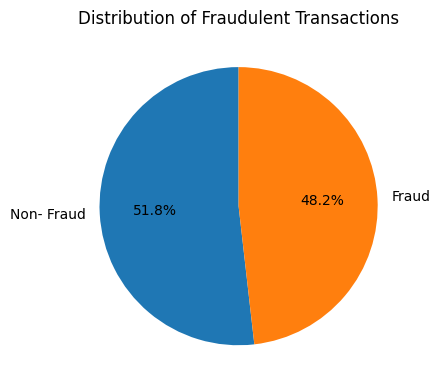

In [16]:
plt.figure(figsize = (5,4))
plt.pie(df['is_fraud'].value_counts(), labels=['Non- Fraud', 'Fraud'], autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Fraudulent Transactions')
plt.tight_layout()
plt.show()

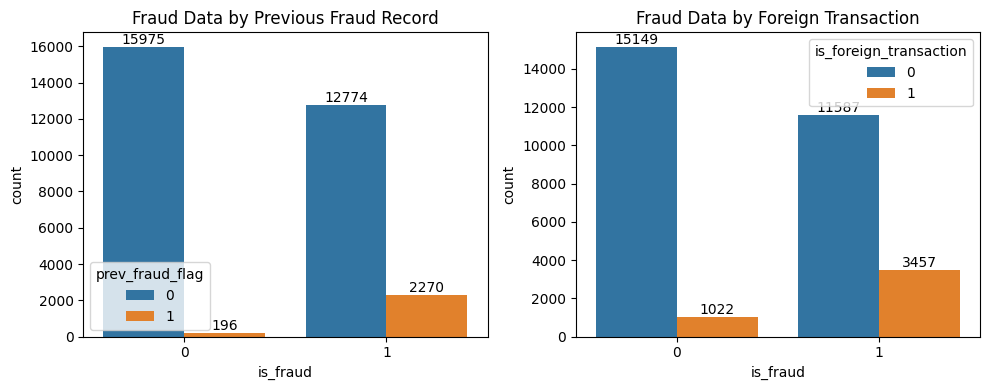

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x = 'is_fraud', data = df, hue = 'prev_fraud_flag', ax=axes[0])
sns.countplot(x = 'is_fraud', data = df, hue = 'is_foreign_transaction', ax=axes[1])
for container in axes[0].containers:
    axes[0].bar_label(container)

for container in axes[1].containers:
    axes[1].bar_label(container)

plt.title('Fraud Detection by Diffrent Features') 
axes[0].set_title('Fraud Data by Previous Fraud Record')
axes[1].set_title('Fraud Data by Foreign Transaction')
plt.tight_layout()
plt.show()

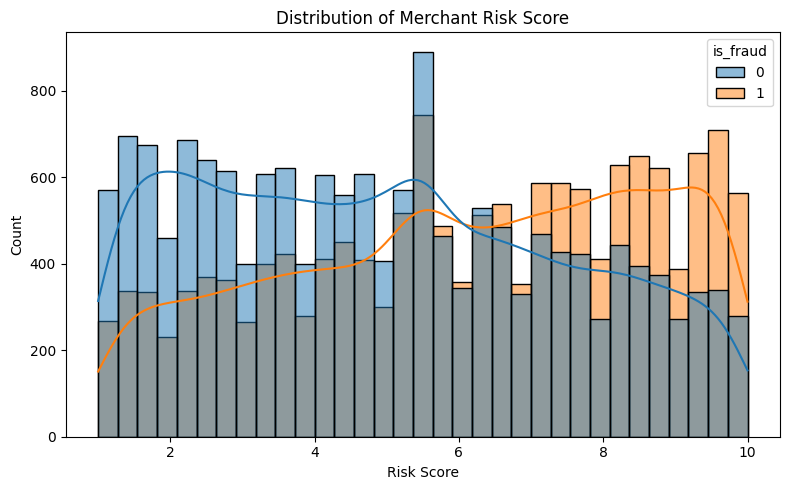

In [18]:
plt.figure(figsize = (8,5))
sns.histplot(data=df, x='merchant_risk_score', hue='is_fraud', kde=True)
plt.xlabel('Risk Score')
plt.title('Distribution of Merchant Risk Score')
plt.tight_layout()

In [19]:
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41,2453.81,12686.50,21,0,9,0,2438.2,5.2,0
1,49,1574.12,36337.02,37,0,4,0,2967.1,8.4,1
2,38,14897.42,23295.64,21,0,0,0,4703.6,3.7,0
3,38,9927.23,38586.08,46,0,17,0,4281.2,5.5,1
4,61,12914.13,2013.73,34,0,11,0,4366.7,9.7,1


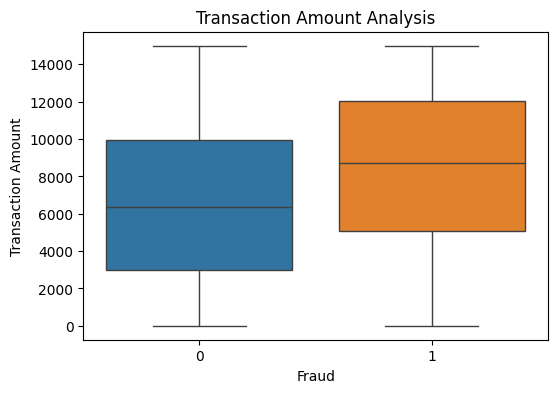

In [20]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='is_fraud', y='transaction_amount', data=df,hue = 'is_fraud', palette=['#1f77b4', '#ff7f0e'], legend = False)
plt.title('Transaction Amount Analysis')
plt.xlabel('Fraud')
plt.ylabel('Transaction Amount')
plt.show()

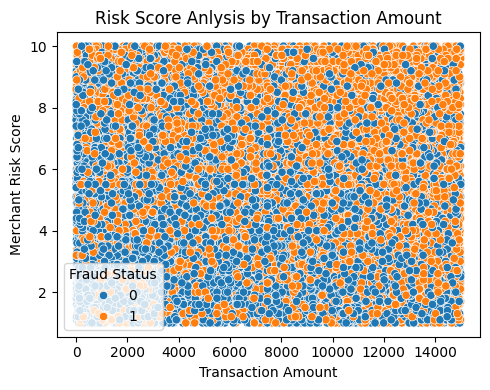

In [21]:
plt.figure(figsize=(5, 4))
sns.scatterplot(y='merchant_risk_score', x='transaction_amount', hue='is_fraud', data=df)
plt.title('Risk Score Anlysis by Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Merchant Risk Score')
plt.legend(title='Fraud Status', loc='lower left')
plt.tight_layout()
plt.show()

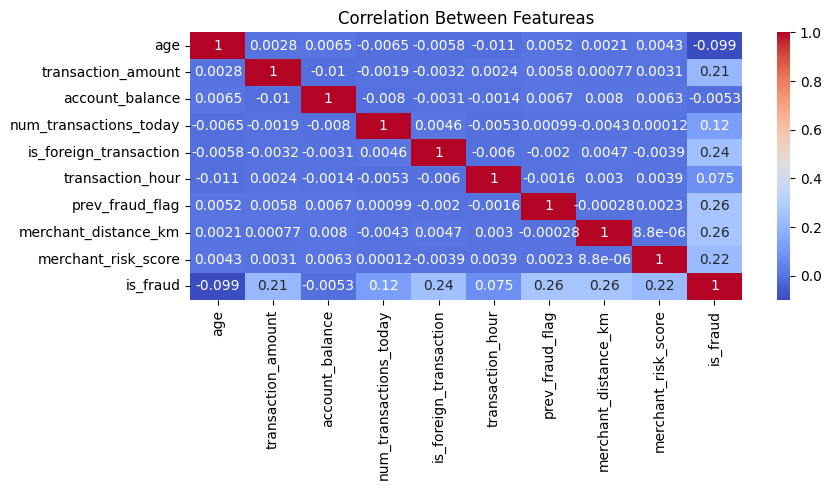

In [22]:
plt.figure(figsize=(9,5))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Featureas')
plt.tight_layout()
plt.show()